# Seoul Bike Demand Forecasting with Poisson Gradient Boosting

This project predicts the number of public bicycles rented during each hour in Seoul.

The target is a non-negative count. Demand also changes non-linearly according to hour, weather, season, holidays and whether the bike-sharing system is operating.

The project develops:

1. A historical hourly baseline.
2. A standard squared-error gradient-boosting model.
3. A count-aware Poisson gradient-boosting model.
4. Quantile models that produce an 80% prediction interval.

The data is divided chronologically so the models are trained on earlier observations and evaluated on later observations. This better represents forecasting than a random train-test split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    mean_poisson_deviance,
    mean_pinball_loss,
    r2_score
)

SEED = 42
sns.set_theme(style="whitegrid")

## 1. Dataset

The Seoul Bike Sharing Demand dataset contains 8,760 hourly observations covering approximately one year.

The target is `Rented Bike Count`.

Predictors include:

- hour of day;
- temperature;
- humidity;
- wind speed;
- visibility;
- dew-point temperature;
- solar radiation;
- rainfall;
- snowfall;
- season;
- holiday status;
- whether the bike-sharing system was functioning.

The model assumes that calendar information and a weather estimate are available for the forecasted hour.

Because the dataset contains observed rather than forecast weather, real operational performance may be lower when weather forecasts are inaccurate.

In [4]:
DATA_URL = (
    "https://archive.ics.uci.edu/static/public/560/"
    "seoul%2Bbike%2Bsharing%2Bdemand.zip"
)

raw_df = pd.read_csv(
    DATA_URL,
    compression="zip",
    encoding="unicode_escape"
)

print("Dataset shape:", raw_df.shape)
raw_df.head()

Dataset shape: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
column_names = {
    "Date": "date",
    "Rented Bike Count": "rented_bikes",
    "Hour": "hour",
    "Temperature(°C)": "temperature",
    "Humidity(%)": "humidity",
    "Wind speed (m/s)": "wind_speed",
    "Visibility (10m)": "visibility",
    "Dew point temperature(°C)": "dew_point",
    "Solar Radiation (MJ/m2)": "solar_radiation",
    "Rainfall(mm)": "rainfall",
    "Snowfall (cm)": "snowfall",
    "Seasons": "season",
    "Holiday": "holiday",
    "Functioning Day": "functioning_day"
}

df = raw_df.rename(columns=column_names).copy()

df.head()

,date,rented_bikes,hour,temperature,humidity,wind_speed,visibility,dew_point,solar_radiation,rainfall,snowfall,season,holiday,functioning_day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [7]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y"
)

df["timestamp"] = (
    df["date"]
    + pd.to_timedelta(df["hour"], unit="h")
)

df = (
    df.sort_values("timestamp")
    .reset_index(drop=True)
)

print("First observation:", df["timestamp"].min())
print("Last observation:", df["timestamp"].max())

First observation: 2017-12-01 00:00:00
Last observation: 2018-11-30 23:00:00


In [8]:
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_year"] = df["date"].dt.dayofyear
df["month"] = df["date"].dt.month
df["weekend"] = (df["day_of_week"] >= 5).astype(int)

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

df["doy_sin"] = np.sin(
    2 * np.pi * df["day_of_year"] / 365.25
)

df["doy_cos"] = np.cos(
    2 * np.pi * df["day_of_year"] / 365.25
)

In [9]:
data_summary = pd.Series({
    "observations": len(df),
    "missing_values": df.isna().sum().sum(),
    "duplicate_timestamps": df["timestamp"].duplicated().sum(),
    "minimum_demand": df["rented_bikes"].min(),
    "median_demand": df["rented_bikes"].median(),
    "mean_demand": df["rented_bikes"].mean(),
    "maximum_demand": df["rented_bikes"].max(),
    "zero_demand_hours": (df["rented_bikes"] == 0).sum()
})

data_summary

observations            8760.000000
missing_values             0.000000
duplicate_timestamps       0.000000
minimum_demand             0.000000
median_demand            504.500000
mean_demand              704.602055
maximum_demand          3556.000000
zero_demand_hours        295.000000
dtype: float64

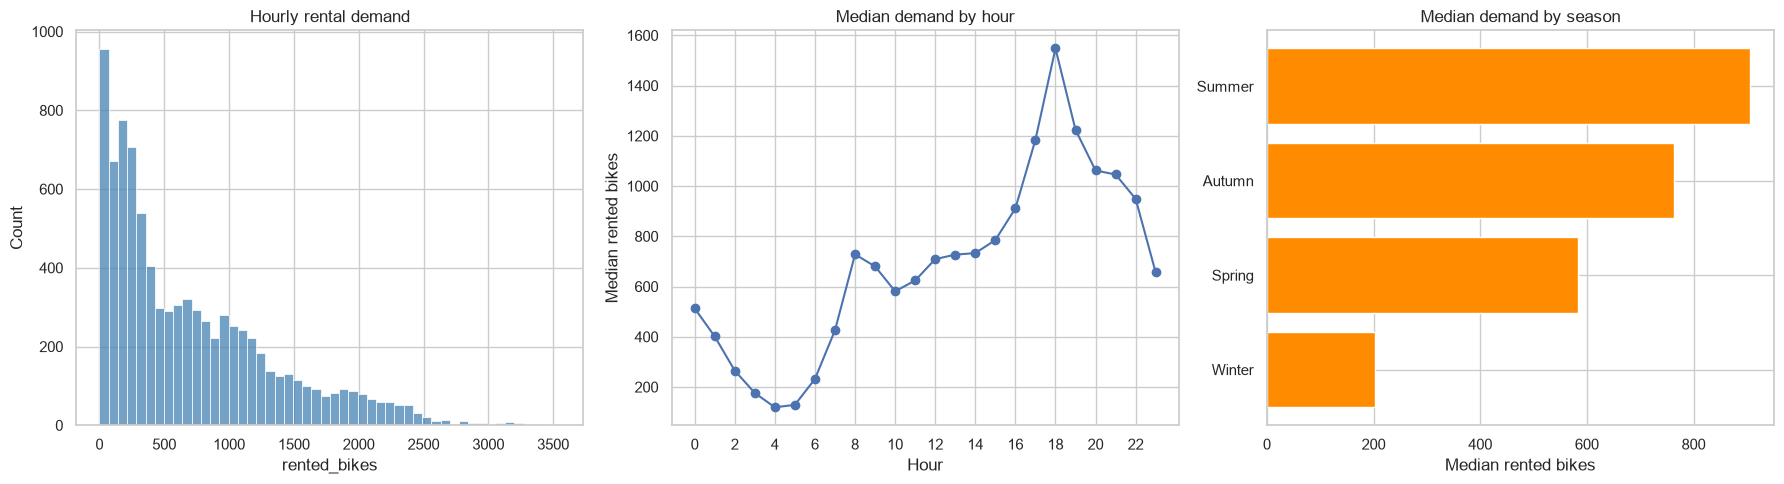

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    df["rented_bikes"],
    bins=50,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Hourly rental demand")

hourly_median = (
    df.groupby("hour")["rented_bikes"]
    .median()
)

axes[1].plot(
    hourly_median.index,
    hourly_median.values,
    marker="o"
)
axes[1].set_title("Median demand by hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Median rented bikes")
axes[1].set_xticks(range(0, 24, 2))

seasonal_median = (
    df.groupby("season")["rented_bikes"]
    .median()
    .sort_values()
)

axes[2].barh(
    seasonal_median.index,
    seasonal_median.values,
    color="darkorange"
)
axes[2].set_title("Median demand by season")
axes[2].set_xlabel("Median rented bikes")

plt.tight_layout()
plt.show()

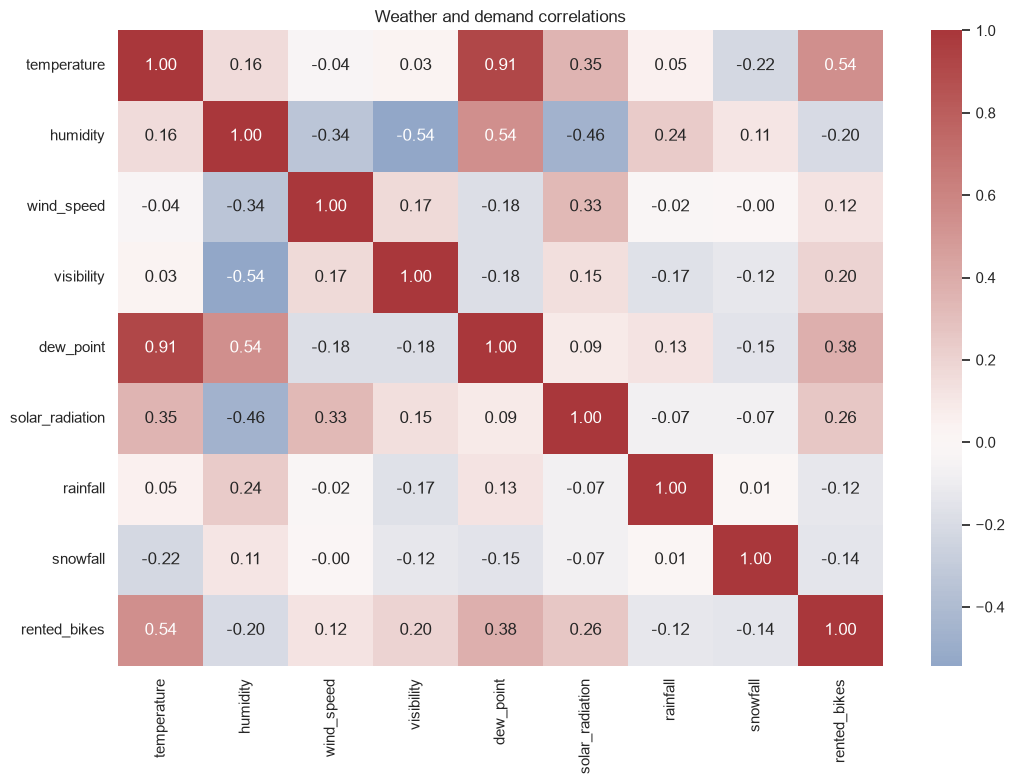

In [11]:
weather_features = [
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "rented_bikes"
]

plt.figure(figsize=(11, 8))

sns.heatmap(
    df[weather_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)

plt.title("Weather and demand correlations")
plt.tight_layout()
plt.show()

## Exploratory findings

- Total observations: **8,760**
- Date range: **1 December 2017 to 30 November 2018**
- Missing values: **0**
- Duplicate timestamps: **0**
- Minimum hourly demand: **0 bikes**
- Median hourly demand: **504.5 bikes**
- Mean hourly demand: **704.60 bikes**
- Maximum hourly demand: **3,556 bikes**
- Zero-demand hours: **295**

The demand distribution is strongly right-skewed. Most hours recorded relatively low or moderate demand, while a smaller number of high-demand hours extended beyond 2,500 rentals. The mean of 704.60 being substantially higher than the median of 504.5 also demonstrates the influence of these high-demand periods.

Hourly demand was lowest at approximately 04:00 and 05:00. It began rising after 06:00 and showed a morning commuting peak at 08:00. The strongest overall period occurred during the evening commute:

- 18:00: median demand of **1,548 bikes**
- 19:00: median demand of **1,224 bikes**
- 17:00: median demand of **1,184 bikes**

Median seasonal demand was:

- Summer: **905.5 bikes**
- Autumn: **763.5 bikes**
- Spring: **583.0 bikes**
- Winter: **203.0 bikes**

Summer therefore had the highest median demand, while winter had the lowest.

Temperature had the strongest positive correlation with demand at **0.54**. Dew-point temperature also had a moderate positive correlation of **0.38**.

Humidity had the strongest negative correlation with demand at **−0.20**, followed by snowfall at −0.14 and rainfall at −0.12.

The strong correlation of 0.91 between temperature and dew point also shows that these two predictors contain overlapping information. All relationships are descriptive and do not prove that the weather variables caused the observed demand changes.

## 2. Chronological train-validation-test split

A random split would allow observations from later months to appear in the training set while earlier observations appear in the test set.

That would not represent real forecasting.

The data is therefore divided in chronological order:

- First 70%: training set
- Next 15%: validation set
- Final 15%: test set

The validation set is used to choose model settings. The test set remains untouched until the final evaluation.

In [12]:
train_end = int(len(df) * 0.70)
validation_end = int(len(df) * 0.85)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[
    train_end:validation_end
].copy()
test_df = df.iloc[
    validation_end:
].copy()

split_summary = pd.DataFrame({
    "split": ["Training", "Validation", "Test"],
    "observations": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "start": [
        train_df["timestamp"].min(),
        validation_df["timestamp"].min(),
        test_df["timestamp"].min()
    ],
    "end": [
        train_df["timestamp"].max(),
        validation_df["timestamp"].max(),
        test_df["timestamp"].max()
    ],
    "mean_demand": [
        train_df["rented_bikes"].mean(),
        validation_df["rented_bikes"].mean(),
        test_df["rented_bikes"].mean()
    ]
})

split_summary

,split,observations,start,end,mean_demand
0,Training,6132,2017-12-01 00:00:00,2018-08-13 11:00:00,649.903294
1,Validation,1314,2018-08-13 12:00:00,2018-10-07 05:00:00,877.216134
2,Test,1314,2018-10-07 06:00:00,2018-11-30 23:00:00,787.248858


## Chronological split

| Split | Observations | Date range | Mean demand |
|---|---:|---|---:|
| Training | **6,132** | **1 December 2017 00:00 – 13 August 2018 11:00** | **649.90 bikes** |
| Validation | **1,314** | **13 August 2018 12:00 – 7 October 2018 05:00** | **877.22 bikes** |
| Test | **1,314** | **7 October 2018 06:00 – 30 November 2018 23:00** | **787.25 bikes** |

Mean demand increased substantially from 649.90 bikes in the training period to 877.22 bikes in the validation period. It then decreased to 787.25 bikes in the test period but remained considerably higher than in the original training period.

This demonstrates a temporal distribution shift: the later periods did not have the same demand level or seasonal conditions as the earlier observations.

The chronological evaluation is consequently more difficult and realistic than a random split. The model must generalise from earlier winter, spring and summer observations to later summer and autumn conditions without receiving randomly mixed examples from the future.

In [13]:
numeric_features = [
    "hour",
    "month",
    "weekend",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos"
]

categorical_features = [
    "season",
    "holiday",
    "functioning_day"
]

feature_names = (
    numeric_features
    + categorical_features
)

target_name = "rented_bikes"

X_train = train_df[feature_names]
y_train = train_df[target_name]

X_validation = validation_df[feature_names]
y_validation = validation_df[target_name]

X_test = test_df[feature_names]
y_test = test_df[target_name]

In [14]:
def make_preprocessor():
    return ColumnTransformer([
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ])

In [15]:
def make_model(loss, quantile=None, **model_parameters):
    regressor_parameters = {
        "loss": loss,
        "early_stopping": False,
        "random_state": SEED,
        **model_parameters
    }

    if loss == "quantile":
        regressor_parameters["quantile"] = quantile

    return Pipeline([
        (
            "preprocessing",
            make_preprocessor()
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                **regressor_parameters
            )
        )
    ])

## 3. Poisson gradient boosting

Gradient boosting builds decision trees sequentially.

Each new tree attempts to correct errors made by the current collection of trees. This allows the model to learn non-linear relationships and interactions, such as:

- morning demand behaving differently from evening demand;
- rain having a different effect during rush hour;
- temperature having different effects across seasons.

Poisson loss is suitable because bike rentals are non-negative counts.

It uses a logarithmic link internally, helping the model produce non-negative expected demand. However, the data does not have to follow a perfect theoretical Poisson distribution for the loss to be useful.

In [16]:
candidate_configs = [
    {
        "name": "Conservative",
        "learning_rate": 0.06,
        "max_iter": 250,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 30,
        "l2_regularization": 5.0
    },
    {
        "name": "Balanced",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 2.0
    },
    {
        "name": "Flexible",
        "learning_rate": 0.04,
        "max_iter": 300,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 15,
        "l2_regularization": 5.0
    }
]

In [17]:
def regression_metrics(name, actual, prediction):
    prediction = np.clip(
        np.asarray(prediction),
        0,
        None
    )

    positive_prediction = np.clip(
        prediction,
        1e-6,
        None
    )

    return {
        "model": name,
        "MAE": mean_absolute_error(
            actual,
            prediction
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                prediction
            )
        ),
        "RMSLE": np.sqrt(
            mean_squared_log_error(
                actual,
                prediction
            )
        ),
        "R2": r2_score(
            actual,
            prediction
        ),
        "Poisson_deviance":
            mean_poisson_deviance(
                actual,
                positive_prediction
            ),
        "WAPE": (
            np.abs(
                np.asarray(actual)
                - prediction
            ).sum()
            / np.asarray(actual).sum()
        )
    }

In [18]:
validation_rows = []
candidate_models = {}

for configuration in candidate_configs:
    parameters = configuration.copy()
    model_name = parameters.pop("name")

    model = make_model(
        loss="poisson",
        **parameters
    )

    model.fit(
        X_train,
        y_train
    )

    validation_prediction = np.clip(
        model.predict(X_validation),
        0,
        None
    )

    validation_rows.append(
        regression_metrics(
            model_name,
            y_validation,
            validation_prediction
        )
    )

    candidate_models[model_name] = model

validation_results = pd.DataFrame(
    validation_rows
).sort_values(
    ["MAE", "Poisson_deviance"]
)

validation_results.round(4)

,model,MAE,RMSE,RMSLE,R2,Poisson_deviance,WAPE
0,Conservative,193.9332,289.8552,0.5148,0.8356,82.4362,0.2211
1,Balanced,216.3276,325.7809,0.4750,0.7924,96.8626,0.2466
2,Flexible,218.9053,323.9707,0.4656,0.7947,98.9329,0.2495


In [19]:
best_name = validation_results.iloc[0]["model"]

best_parameters = next(
    {
        key: value
        for key, value in config.items()
        if key != "name"
    }
    for config in candidate_configs
    if config["name"] == best_name
)

print("Selected configuration:", best_name)
print(best_parameters)

Selected configuration: Conservative
{'learning_rate': 0.06, 'max_iter': 250, 'max_leaf_nodes': 15, 'min_samples_leaf': 30, 'l2_regularization': 5.0}


## Model-selection results

| Configuration | MAE | RMSE | RMSLE | R² | Poisson deviance | WAPE |
|---|---:|---:|---:|---:|---:|---:|
| Conservative | **193.9332** | **289.8552** | **0.5148** | **0.8356** | **82.4362** | **0.2211** |
| Balanced | **216.3276** | **325.7809** | **0.4750** | **0.7924** | **96.8626** | **0.2466** |
| Flexible | **218.9053** | **323.9707** | **0.4656** | **0.7947** | **98.9329** | **0.2495** |

The selected configuration was **Conservative**, using:

- Learning rate: **0.06**
- Boosting iterations: **250**
- Maximum leaf nodes: **15**
- Minimum samples per leaf: **30**
- L2 regularisation: **5.0**

The Conservative configuration achieved the lowest validation MAE, RMSE, Poisson deviance and WAPE, as well as the highest R².

Compared with the Balanced configuration, it reduced MAE by approximately 22.39 bikes. Compared with the Flexible configuration, it reduced MAE by approximately 24.97 bikes.

The Balanced and Flexible models achieved lower RMSLE values. This means they handled proportional errors, particularly around smaller demand values, somewhat better. However, they produced worse absolute count predictions and weaker overall explained variation.

The comparison indicates that additional tree complexity did not improve generalisation to the later validation period. The simpler and more strongly regularised model performed better on the main absolute-demand metrics, suggesting that the more flexible alternatives overfitted patterns in the training period.

## 4. Final model comparison

After selecting the configuration, the training and validation sets are combined.

Three test-set models are compared:

1. Historical median demand for each hour and functioning status.
2. Gradient boosting with ordinary squared-error loss.
3. Gradient boosting with Poisson loss.

The test set has not been used during preprocessing, fitting or model selection.

In [20]:
development_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True
)

X_development = development_df[feature_names]
y_development = development_df[target_name]

In [21]:
baseline_table = (
    development_df
    .groupby(
        ["hour", "functioning_day"],
        as_index=False
    )["rented_bikes"]
    .median()
    .rename(
        columns={
            "rented_bikes":
                "baseline_prediction"
        }
    )
)

baseline_prediction = (
    test_df[
        ["hour", "functioning_day"]
    ]
    .merge(
        baseline_table,
        on=["hour", "functioning_day"],
        how="left"
    )["baseline_prediction"]
    .fillna(y_development.median())
    .to_numpy()
)

In [22]:
squared_model = make_model(
    loss="squared_error",
    **best_parameters
)

poisson_model = make_model(
    loss="poisson",
    **best_parameters
)

squared_model.fit(
    X_development,
    y_development
)

poisson_model.fit(
    X_development,
    y_development
)

squared_prediction = np.clip(
    squared_model.predict(X_test),
    0,
    None
)

poisson_prediction = np.clip(
    poisson_model.predict(X_test),
    0,
    None
)

In [23]:
test_results = pd.DataFrame([
    regression_metrics(
        "Historical hourly median",
        y_test,
        baseline_prediction
    ),
    regression_metrics(
        "Squared-error boosting",
        y_test,
        squared_prediction
    ),
    regression_metrics(
        "Poisson boosting",
        y_test,
        poisson_prediction
    )
])

test_results.sort_values("MAE").round(4)

,model,MAE,RMSE,RMSLE,R2,Poisson_deviance,WAPE
2,Poisson boosting,225.9477,312.0819,0.5097,0.6999,128.0815,0.2870
1,Squared-error boosting,257.5527,347.6626,1.0923,0.6275,158.4340,0.3272
0,Historical hourly median,277.0639,404.7762,0.6329,0.4951,188.9450,0.3519


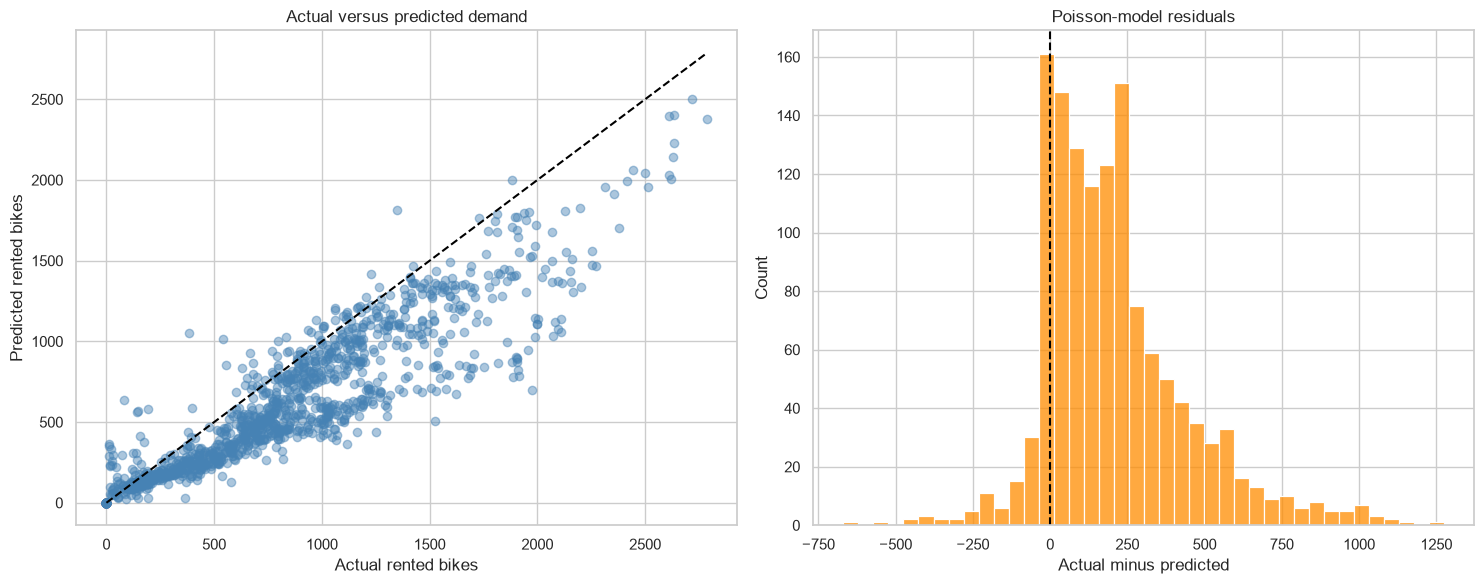

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(
    y_test,
    poisson_prediction,
    alpha=0.45,
    color="steelblue"
)

limit = max(
    y_test.max(),
    poisson_prediction.max()
)

axes[0].plot(
    [0, limit],
    [0, limit],
    "--",
    color="black"
)

axes[0].set_title(
    "Actual versus predicted demand"
)
axes[0].set_xlabel("Actual rented bikes")
axes[0].set_ylabel("Predicted rented bikes")

residuals = (
    np.asarray(y_test)
    - poisson_prediction
)

sns.histplot(
    residuals,
    bins=40,
    ax=axes[1],
    color="darkorange"
)

axes[1].axvline(
    0,
    color="black",
    linestyle="--"
)

axes[1].set_title(
    "Poisson-model residuals"
)
axes[1].set_xlabel(
    "Actual minus predicted"
)

plt.tight_layout()
plt.show()

## Final test-set results

| Model | MAE | RMSE | RMSLE | R² | Poisson deviance | WAPE |
|---|---:|---:|---:|---:|---:|---:|
| Historical hourly median | **277.0639** | **404.7762** | **0.6329** | **0.4951** | **188.9450** | **0.3519** |
| Squared-error boosting | **257.5527** | **347.6626** | **1.0923** | **0.6275** | **158.4340** | **0.3272** |
| Poisson boosting | **225.9477** | **312.0819** | **0.5097** | **0.6999** | **128.0815** | **0.2870** |

Poisson boosting was the best model on every reported test metric.

It achieved:

- MAE: **225.95 bikes**
- RMSE: **312.08 bikes**
- RMSLE: **0.5097**
- R²: **0.6999**
- Poisson deviance: **128.08**
- WAPE: **28.70%**

The Poisson model reduced MAE by approximately **18.45%** relative to the historical hourly median baseline. It also reduced MAE by approximately **12.27%** relative to squared-error boosting.

The result supports using a count-aware Poisson loss for this target. It handled the non-negative, strongly right-skewed rental counts more effectively than ordinary squared-error loss.

The squared-error model still improved MAE, RMSE and R² over the historical baseline. However, its RMSLE of 1.0923 was considerably worse, indicating particularly poor proportional performance around zero and lower-demand observations.

The actual-versus-predicted plot shows that Poisson boosting learned the overall demand relationship. Predictions generally increased as actual demand increased, and many low-to-moderate observations followed the diagonal reasonably well.

However, the model increasingly underestimated high-demand observations. Many points with actual demand above approximately 1,000 bikes fell below the ideal diagonal.

The residual distribution was positively skewed. Because residual was calculated as actual minus predicted, the positive mean residual of approximately **201.63 bikes** indicates systematic underprediction during the test period. Large positive residuals were much more common than equally large negative residuals.

## 5. Quantile prediction intervals

A single prediction does not communicate uncertainty.

Three additional gradient-boosting models estimate:

- 10th percentile: lower plausible demand;
- 50th percentile: median demand;
- 90th percentile: upper plausible demand.

Together, the 10th and 90th percentiles create a nominal 80% prediction interval.

A well-calibrated interval should contain approximately 80% of future observations. Interval width should increase when demand is more uncertain.

In [25]:
quantile_predictions = {}

for quantile in [0.10, 0.50, 0.90]:
    quantile_model = make_model(
        loss="quantile",
        quantile=quantile,
        **best_parameters
    )

    quantile_model.fit(
        X_development,
        y_development
    )

    quantile_predictions[quantile] = (
        np.clip(
            quantile_model.predict(X_test),
            0,
            None
        )
    )

In [26]:
raw_lower = quantile_predictions[0.10]
raw_median = quantile_predictions[0.50]
raw_upper = quantile_predictions[0.90]

crossing = (
    (raw_lower > raw_median)
    | (raw_median > raw_upper)
)

ordered_quantiles = np.sort(
    np.column_stack([
        raw_lower,
        raw_median,
        raw_upper
    ]),
    axis=1
)

lower_prediction = ordered_quantiles[:, 0]
median_prediction = ordered_quantiles[:, 1]
upper_prediction = ordered_quantiles[:, 2]

print(
    "Quantile crossing rate:",
    crossing.mean().round(4)
)

Quantile crossing rate: 0.1416


In [27]:
covered = (
    (np.asarray(y_test) >= lower_prediction)
    & (np.asarray(y_test) <= upper_prediction)
)

interval_width = (
    upper_prediction
    - lower_prediction
)

interval_results = pd.Series({
    "target_coverage": 0.80,
    "empirical_coverage": covered.mean(),
    "average_width": interval_width.mean(),
    "median_width": np.median(interval_width),
    "crossing_rate": crossing.mean(),
    "lower_pinball_loss":
        mean_pinball_loss(
            y_test,
            lower_prediction,
            alpha=0.10
        ),
    "median_pinball_loss":
        mean_pinball_loss(
            y_test,
            median_prediction,
            alpha=0.50
        ),
    "upper_pinball_loss":
        mean_pinball_loss(
            y_test,
            upper_prediction,
            alpha=0.90
        )
})

interval_results.round(4)

target_coverage          0.8000
empirical_coverage       0.2823
average_width          316.4379
median_width           282.1667
crossing_rate            0.1416
lower_pinball_loss      43.9186
median_pinball_loss    134.7889
upper_pinball_loss     133.1081
dtype: float64

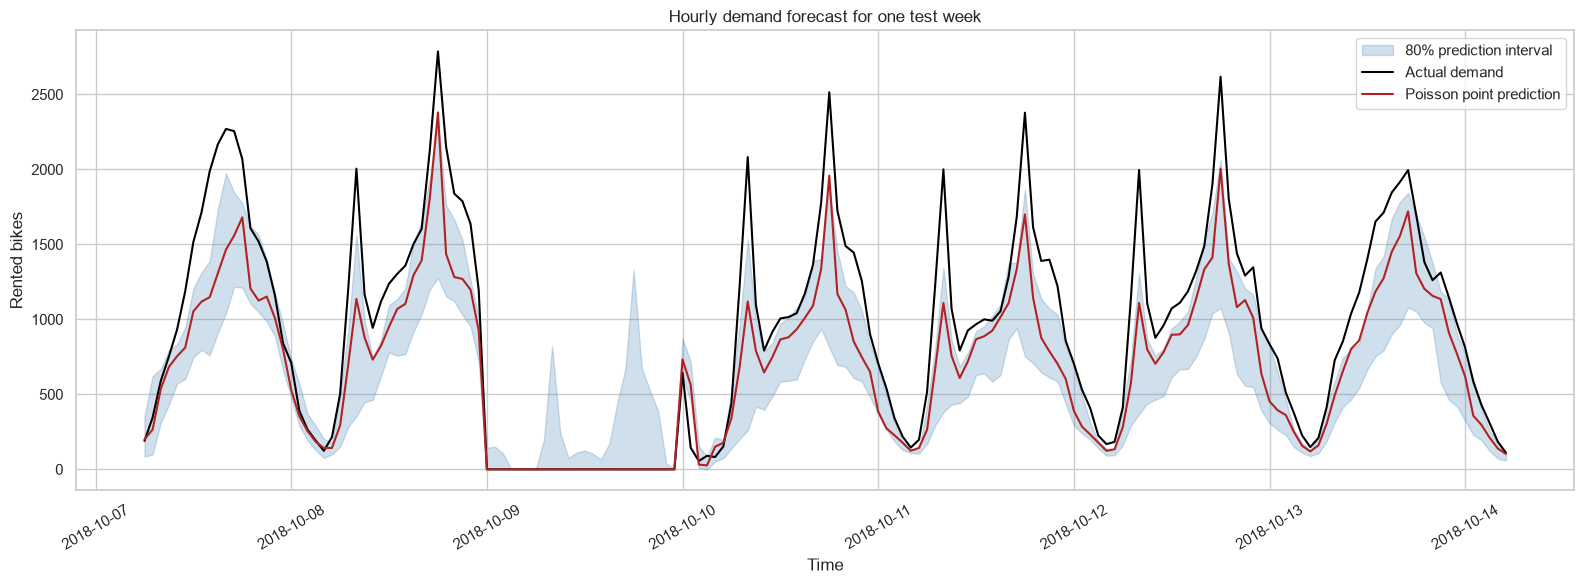

In [28]:
week_end = (
    test_df["timestamp"].iloc[0]
    + pd.Timedelta(days=7)
)

week_mask = (
    test_df["timestamp"] < week_end
)

week_time = test_df.loc[
    week_mask,
    "timestamp"
]

plt.figure(figsize=(16, 6))

plt.fill_between(
    week_time,
    lower_prediction[week_mask],
    upper_prediction[week_mask],
    alpha=0.25,
    color="steelblue",
    label="80% prediction interval"
)

plt.plot(
    week_time,
    y_test.loc[week_mask],
    color="black",
    label="Actual demand"
)

plt.plot(
    week_time,
    poisson_prediction[week_mask],
    color="firebrick",
    label="Poisson point prediction"
)

plt.title(
    "Hourly demand forecast for one test week"
)
plt.xlabel("Time")
plt.ylabel("Rented bikes")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Prediction-interval results

- Target coverage: **80%**
- Empirical coverage: **28.23%**
- Coverage shortfall: **51.77 percentage points**
- Average interval width: **316.44 bikes**
- Median interval width: **282.17 bikes**
- Quantile crossing rate: **14.16%**
- Lower-quantile pinball loss: **43.9186**
- Median pinball loss: **134.7889**
- Upper-quantile pinball loss: **133.1081**

The prediction interval was severely under-calibrated. It captured only 28.23% of test observations instead of the intended 80%.

Approximately:

- **69.25%** of actual observations were above the predicted upper boundary;
- **4.57%** were below the predicted lower boundary;
- **28.23%** were inside the interval.

This imbalance shows that the intervals were not simply too narrow around a correct centre. The complete predictive distribution was generally positioned too low because the models systematically underestimated later-period demand.

Interval width did increase during high-demand hours. For example:

- 08:00 average width: approximately **656.60 bikes**
- 18:00 average width: approximately **691.01 bikes**

However, increased width was not sufficient to correct the downward shift. Coverage at 08:00 was only 14.5%, while coverage at 18:00 was only 20.0%.

The weekly forecast confirms that the interval missed most morning and evening demand peaks. The actual black line frequently rose above both the Poisson point prediction and the upper interval boundary.

The 14.16% quantile-crossing rate is also non-trivial. Sorting corrected the numerical ordering of the three quantiles, but it did not solve the underlying calibration problem.

Therefore, the quantile models successfully produced variable-width ranges, but those ranges should not be treated as reliable 80% prediction intervals on this test period. A future version would require validation-based interval calibration or a conformal prediction method designed to handle forecast uncertainty more robustly.

In [29]:
analysis_df = test_df[
    [
        "timestamp",
        "hour",
        "season",
        "temperature",
        "rainfall",
        "functioning_day"
    ]
].copy()

analysis_df["actual"] = np.asarray(y_test)
analysis_df["prediction"] = poisson_prediction

analysis_df["residual"] = (
    analysis_df["actual"]
    - analysis_df["prediction"]
)

analysis_df["absolute_error"] = (
    analysis_df["residual"].abs()
)

hourly_error = (
    analysis_df
    .groupby("hour")
    .agg(
        observations=("actual", "size"),
        mean_actual=("actual", "mean"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean")
    )
    .reset_index()
)

hourly_error.round(2)

,hour,observations,mean_actual,MAE,mean_residual
0,0,54,557.61,208.77,194.97
1,1,54,437.80,187.32,158.68
2,2,54,302.85,105.16,89.10
3,3,54,207.30,66.97,64.74
4,4,54,135.96,37.68,29.23
5,5,54,135.80,32.13,24.08
6,6,55,304.05,108.63,107.04
7,7,55,726.73,359.34,337.74
8,8,55,1300.22,599.00,571.59
9,9,55,793.62,288.90,281.43


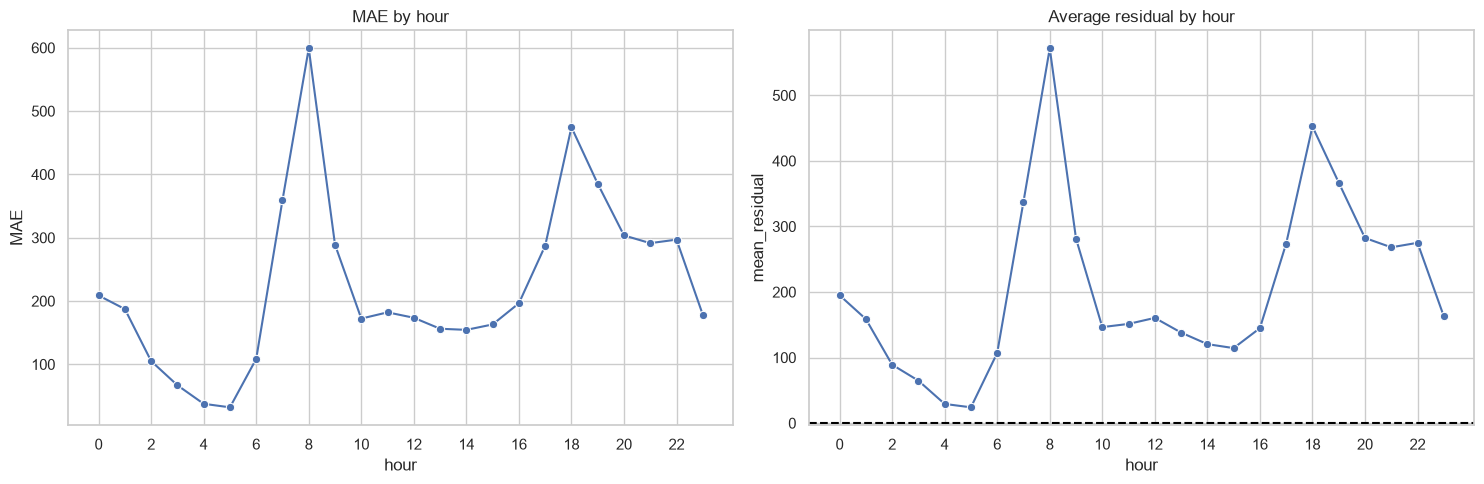

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=hourly_error,
    x="hour",
    y="MAE",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("MAE by hour")
axes[0].set_xticks(range(0, 24, 2))

sns.lineplot(
    data=hourly_error,
    x="hour",
    y="mean_residual",
    marker="o",
    ax=axes[1]
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--"
)

axes[1].set_title(
    "Average residual by hour"
)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

In [31]:
largest_errors = (
    analysis_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

largest_errors.round(2)

,timestamp,hour,season,temperature,rainfall,functioning_day,actual,prediction,residual,absolute_error
8144,2018-11-05 08:00:00,8,Autumn,7.2,0.0,Yes,1975,700.23,1274.77,1274.77
8360,2018-11-14 08:00:00,8,Autumn,5.0,0.0,Yes,1916,786.00,1130.00,1130.00
7976,2018-10-29 08:00:00,8,Autumn,5.1,0.0,Yes,1888,777.39,1110.61,1110.61
8336,2018-11-13 08:00:00,8,Autumn,4.7,0.0,Yes,1910,821.05,1088.95,1088.95
7856,2018-10-24 08:00:00,8,Autumn,8.1,0.0,Yes,2108,1059.61,1048.39,1048.39
8010,2018-10-30 18:00:00,18,Autumn,8.4,0.0,Yes,2074,1035.50,1038.50,1038.50
8072,2018-11-02 08:00:00,8,Autumn,4.7,0.0,Yes,1906,869.94,1036.06,1036.06
8648,2018-11-26 08:00:00,8,Autumn,2.0,0.0,Yes,1524,505.22,1018.78,1018.78
8490,2018-11-19 18:00:00,18,Autumn,7.5,0.0,Yes,1904,887.76,1016.24,1016.24
8034,2018-10-31 18:00:00,18,Autumn,9.4,0.0,Yes,2094,1078.97,1015.03,1015.03


## Final interpretation

### Error patterns

The largest hourly MAEs were:

1. **08:00 — 599.00 bikes**
2. **18:00 — 474.52 bikes**
3. **19:00 — 385.26 bikes**
4. **07:00 — 359.34 bikes**
5. **20:00 — 303.64 bikes**
6. **22:00 — 297.00 bikes**
7. **21:00 — 291.42 bikes**
8. **09:00 — 288.90 bikes**
9. **17:00 — 287.37 bikes**

The model had a positive mean residual during every hour of the day, meaning that it systematically underpredicted throughout the test period.

Underprediction was strongest during commuting hours:

- 08:00 mean residual: **+571.59 bikes**
- 18:00 mean residual: **+452.47 bikes**
- 19:00 mean residual: **+366.96 bikes**
- 07:00 mean residual: **+337.74 bikes**

The largest individual error occurred at 08:00 on 5 November 2018. Actual demand was 1,975 bikes, while the model predicted only 700.23, producing an error of 1,274.77 bikes.

Most of the fifteen largest errors occurred:

- at 08:00 or 18:00;
- during autumn;
- on functioning days;
- without rainfall;
- at relatively cool temperatures between approximately 1.4°C and 9.9°C.

Actual demand in these cases was generally between approximately 1,500 and 2,100 bikes, while predictions were often between only 500 and 1,140.

This indicates that the model learned the general shape of hourly demand but did not capture the full size of the later-autumn commuting peaks. Calendar and observed weather information alone were insufficient to explain this increase.

### Final conclusion

The project developed a chronological bike-demand forecasting system using:

1. A historical hourly baseline.
2. Squared-error gradient boosting.
3. Count-aware Poisson gradient boosting.
4. Quantile prediction intervals.

Poisson boosting was the strongest point model. It achieved an MAE of 225.95 bikes, RMSE of 312.08 bikes and R² of 0.6999.

It reduced MAE by 18.45% relative to the historical baseline and by 12.27% relative to squared-error boosting. Poisson loss was therefore more effective in practice for the non-negative, right-skewed count target.

However, the model systematically underestimated the later test period, especially at 08:00 and 18:00. This shows that good overall point-prediction metrics can coexist with important operational failures during the hours when accurate allocation may matter most.

The nominal 80% interval achieved only 28.23% coverage. Its uncertainty estimates were therefore severely under-calibrated and should not be used operationally.

Overall, the project demonstrates both the value and limitations of count-aware forecasting:

- Poisson boosting produced useful improvements over simpler alternatives.
- Chronological evaluation exposed a real temporal distribution shift.
- Rush-hour peaks remained difficult to predict.
- Separately trained quantile models did not automatically produce reliable future uncertainty intervals.

### Practical limitations

The project uses observed weather values. A real forecasting system would instead receive weather forecasts containing their own uncertainty.

It also does not include:

- station-level bicycle availability;
- recent rental-demand lags;
- long-term demand growth;
- public transport disruptions;
- major events;
- bicycle-lane closures;
- station capacity;
- neighbourhood-level travel patterns.

The model should therefore be treated as an educational city-wide forecasting experiment rather than a deployment-ready bicycle allocation system.